In [22]:
import pandas as pd

In [23]:
df=pd.read_csv('data/spam.csv', encoding='latin-1')


In [24]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [26]:
#Removing useless columns
df=df[['v1','v2']]

In [27]:
#labeling columns
df.columns=['label','message']

In [28]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [29]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

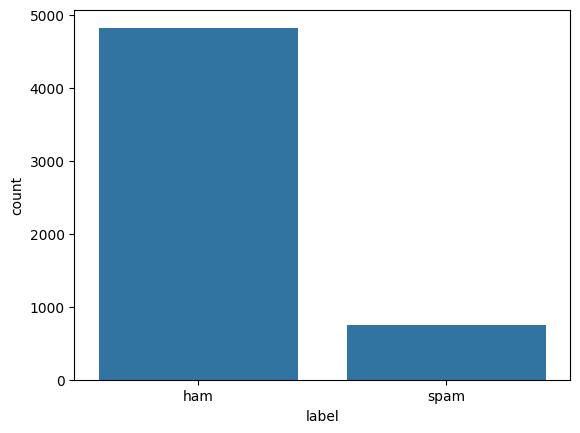

In [30]:
#Visualisation of spam vs ham
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label',data=df)
plt.show()


In [31]:
#Checking for duplicates
df.duplicated().sum()

np.int64(403)

In [32]:
#Dropping duplicates
df = df.drop_duplicates()

In [33]:
print(df.shape)

(5169, 2)


In [34]:
#Vectorization
X=df['message']
y=df['label']

In [35]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
#Converting text using Bag Of Words method

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

In [37]:
#Using multinomial Naive Baye's as data is in text form
from sklearn.naive_bayes import MultinomialNB

model=MultinomialNB()
model.fit(X_train_cv,y_train)
y_pred=model.predict(X_test_cv)

In [38]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

print("Accuracy Score: ",accuracy_score(y_test,y_pred))

print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy Score:  0.9854932301740812
Classification Report:
               precision    recall  f1-score   support

         ham       0.99      1.00      0.99       889
        spam       0.99      0.91      0.95       145

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



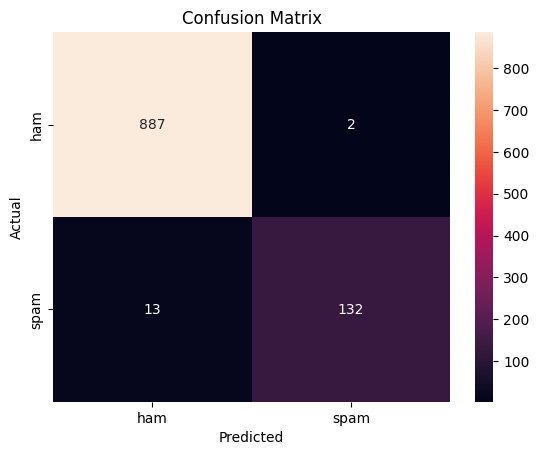

In [39]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['ham','spam'],
    yticklabels=['ham','spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()